In [8]:
#imported packages
import arff
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
from sklearn.inspection import permutation_importance
import joblib

In [9]:
with open('Training Dataset.arff', 'r') as f:
    dataset = arff.load(f)

df = pd.DataFrame(dataset['data'], columns=[attr[0] for attr in dataset['attributes']])
df=df.dropna(axis=1)

In [10]:
#axis=1 means drop columns
X = df.drop('Result', axis=1).astype(float)
y=df['Result'].astype(int)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.2, random_state = 67, stratify=y)
print(f"X train data: {X_train.shape[0]}")
print(f"X test data: {X_test.shape[0]}")

X train data: 8844
X test data: 2211


In [11]:
#Gaussian NB Init
GNB = GaussianNB()
GNB.fit(X_train, y_train)
GNB_predictions = GNB.predict(X_test)
GNB_score = accuracy_score(y_test, GNB_predictions)
print (f"GNB accuracy: {GNB_score}")

GNB accuracy: 0.5893260967887833


In [12]:
#KNN init
knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(X_train, y_train)
knn_predictions = knn.predict(X_test)
knn_score = accuracy_score(y_test, knn_predictions)
print (f"KNN accuracy: {knn_score}")

KNN accuracy: 0.9439167797376753


In [13]:
#Decision Tree init
tree_model = DecisionTreeClassifier(
    criterion = 'gini',
    max_depth = 5,
    min_samples_split = 2,
    random_state = 67
)
tree_model.fit(X_train, y_train)
tree_predictions = tree_model.predict(X_test)
tree_score = accuracy_score(y_test, tree_predictions)
print (f"Decision Tree Accuracy: {tree_score}")

Decision Tree Accuracy: 0.9185888738127544


In [14]:
#create dictionary of results for ease of use in later cells
results = {
    "Gaussian NB": {"y_pred": GNB_predictions,    "model": GNB},
    "KNN": {"y_pred": knn_predictions,    "model": knn},
    "Decision Tree": {"y_pred": tree_predictions,   "model": tree_model}
}

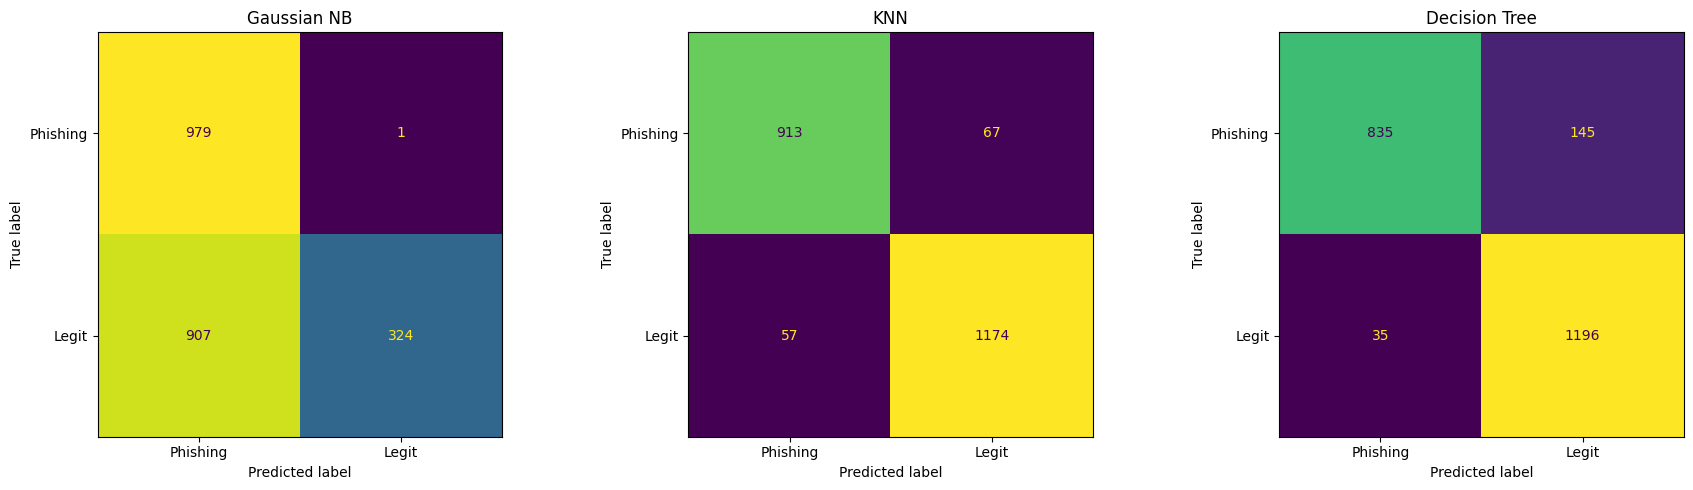

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
#for each plot frame, model name, and data within each model
#in zip(current plot frame, data in plot frame)...
for ax, (name, result) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, result["y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Phishing", "Legit"])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [16]:
for name, result in results.items():
    #f1 is the mean of precision and recall
    cv_scores = cross_val_score(result["model"], X_scaled, y, cv=5, scoring='f1')
    print(f"{name}: Mean F1 = {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


Gaussian NB: Mean F1 = 0.4393 (+/- 0.0244)
KNN: Mean F1 = 0.9480 (+/- 0.0110)
Decision Tree: Mean F1 = 0.9315 (+/- 0.0057)


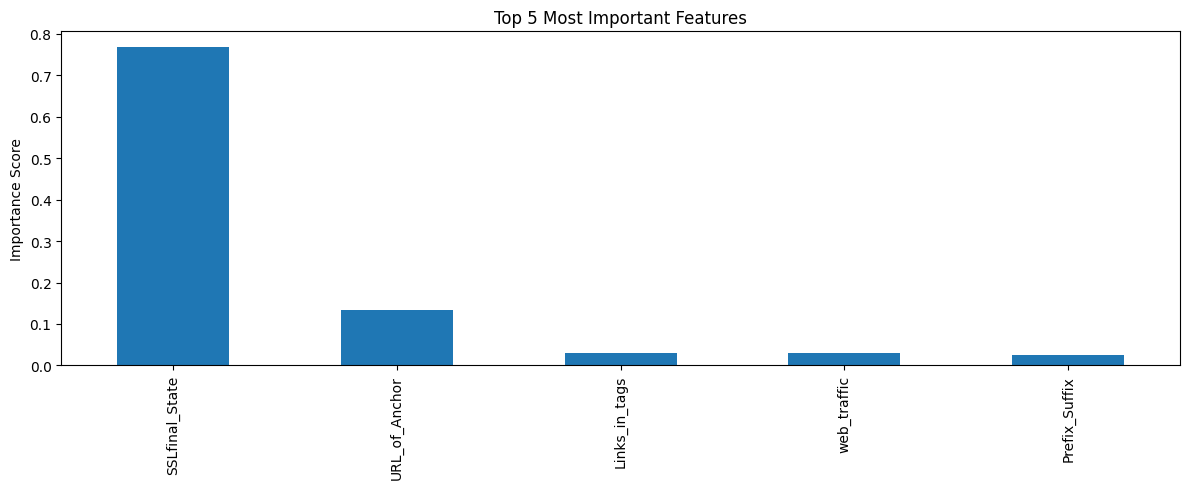

In [17]:
#feature importance
dt_model = results["Decision Tree"]["model"]
feature_names = df.drop('Result', axis=1).columns

importances = pd.Series(dt_model.feature_importances_, index=feature_names)
importances.sort_values(ascending=False).head(5).plot(kind='bar', figsize=(12,5))
plt.title("Top 5 Most Important Features")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

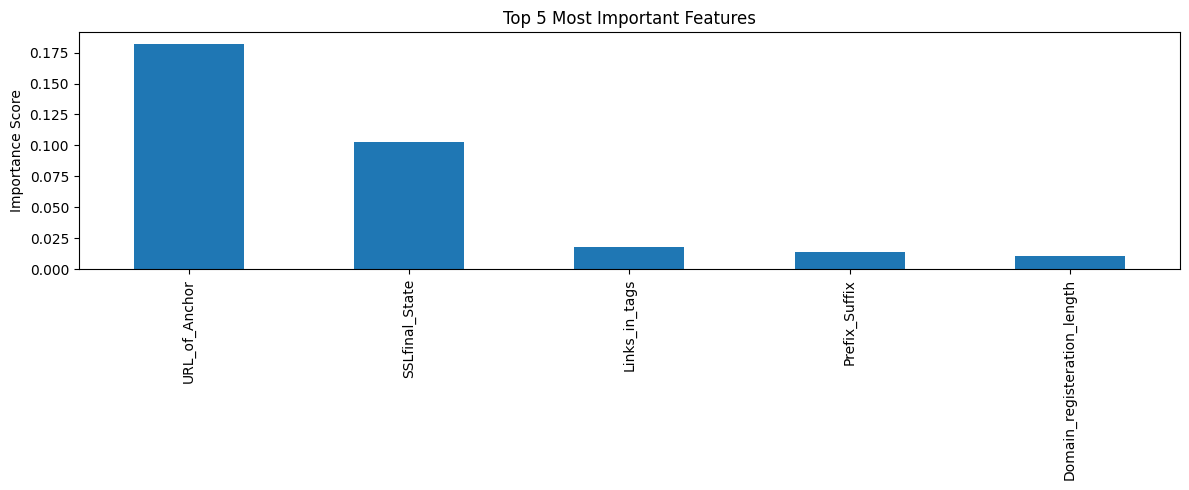

In [20]:
#permutation importance
dt_model = results["Decision Tree"]["model"]
feature_names = df.drop('Result', axis=1).columns

result = permutation_importance(dt_model, X_test, y_test, n_repeats=10, random_state=67)
importances = pd.Series(result.importances_mean, index=feature_names)

importances.sort_values(ascending=False).head(5).plot(kind='bar', figsize=(12,5))
plt.title("Top 5 Most Important Features")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

In [12]:
best_model = results["Decision Tree"]["model"]
joblib.dump(best_model, 'phishing_classifier.pkl')
joblib.dump(scaler, 'scaler.pkl')
print ("Model Saved")

Model Saved


In [15]:
model = joblib.load('phishing_classifier.pkl')
scaler = joblib.load('scaler.pkl')

def predict_url_features(feature_values):
    features_scaled = scaler.transform([feature_values])
    prediction = model.predict(features_scaled)[0]
    return "Phishing URL" if prediction == -1 else "Good URL"
sample = X_test[0]
print (predict_url_features(sample))

Good URL


C:\Users\bshka\downloads\Cyber-Projects\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
#while(True):
    #url = input("Input a URL to check: ")
    #features = extract_features(url)
    #prediction = model.predict([listfeatures.values())])
    #print("Phishing Detected" if prediction[0]=1 else "Safe")